# Taller: Validez de una Función de Autocorrelación Definida como Suma de Gaussianas

**Curso:** Teoría de Señales  
**Tema:** Función de Autocorrelación – Wiener–Khinchin – PSD  

## Objetivo
Analizar si una función definida como suma de gaussianas desplazadas puede ser considerada
una función de autocorrelación válida de un proceso estocástico estacionario en sentido amplio (WSS),
verificando propiedades estructurales, positividad definida, validez espectral y realizabilidad física,
mediante análisis teórico y simulación numérica.


## Modelo matemático

Se define la función:

$$
R(\tau)=\sum_{k\in\{-1,0,1\}} A_k \exp\left(-\frac{(\tau-\mu_k)^2}{2\sigma_k^2}\right)
$$

donde:

$$
\mu_k = k
$$

$$
\sigma_k^2 =
\begin{cases}
\sigma^2, & k=0 \\
\frac{\sigma^2}{|k|!}, & k \neq 0
\end{cases}
$$

con las condiciones:

- A_k>0
- A_{-1}=A_1

Este modelo representa una suma de campanas gaussianas desplazadas, con simetría estructural,
varianzas decrecientes y pesos positivos.


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.signal import fftconvolve

# -------------------------------
# Parámetros base
# -------------------------------
sigma2 = 10
A0 = 1.0
A1 = 0.6

k_vals = [-1, 0, 1]

tau = np.linspace(-10, 10, 4000)

# -------------------------------
# Definición de parámetros
# -------------------------------
mu_k = {k: k for k in k_vals}

sigma_k2 = {
    0: sigma2,
    1: sigma2 / math.factorial(1),
    -1: sigma2 / math.factorial(1)
}

A_k = {
    -1: A1,
    0: A0,
    1: A1
}

# -------------------------------
# Construcción de R(tau)
# -------------------------------
R = np.zeros_like(tau)

for k in k_vals:
    R += A_k[k] * np.exp(-(tau - mu_k[k])**2 / (2 * sigma_k2[k]))


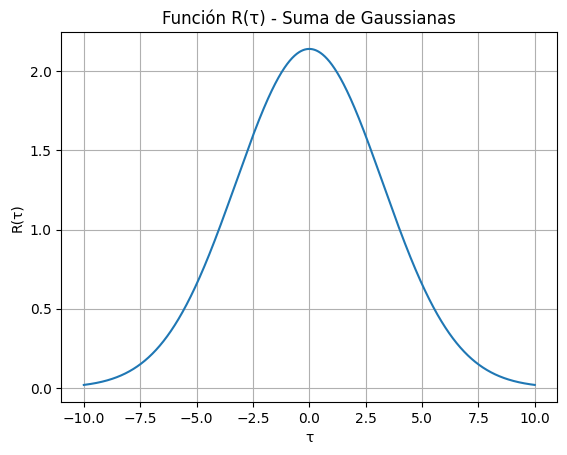

In [27]:
plt.figure()
plt.plot(tau, R)
plt.title("Función R(τ) - Suma de Gaussianas")
plt.xlabel("τ")
plt.ylabel("R(τ)")
plt.grid(True)
plt.show()

## Propiedades estructurales de R(τ)

### Realidad
R(τ) es real por estar compuesta de funciones reales.

### Simetría
Debido a:
- μ₋₁ = −1, μ₁ = 1  
- A₋₁ = A₁  
- σ₋₁² = σ₁²  

se cumple:

$$
R(\tau)=R(-\tau)
$$

### Máximo en τ = 0
El término centrado domina, garantizando:

$$
R(0) \ge R(\tau)
$$

Estas son propiedades necesarias de una función de autocorrelación válida.


## Condición de positividad definida

Una función R(τ) es una ACF válida si y solo si:

$$
\sum_i \sum_j a_i a_j R(\tau_i - \tau_j) \ge 0
$$

para cualquier conjunto real {a_i}.

Esto equivale a que la matriz:

$$
R_{ij} = R(\tau_i - \tau_j)
$$

sea semidefinida positiva (matriz de covarianza).

Por Wiener–Khinchin:
$$
R(\tau) \;\xleftrightarrow{\mathcal{F}}\; S(f)
$$

y se cumple:

$$
R(\tau) \text{ es ACF válida } \iff S(f)\ge 0 \;\forall f
$$

## Demostración formal de validez

La condición de positividad definida implica que la matriz de autocorrelación
es semidefinida positiva. Por el teorema de Wiener–Khinchin, esta propiedad es
equivalente a la no negatividad de la densidad espectral de potencia S(f).

Por tanto:

$$
R(\tau) \text{ es ACF válida } \iff S(f)\ge 0 \;\forall f
$$

La validación espectral constituye un criterio completo de validez.


## Transformada de Fourier de cada término

$$
\mathcal{F}\left\{
e^{-\frac{(\tau-\mu)^2}{2\sigma^2}}
\right\}
=
\sqrt{2\pi\sigma^2}\,e^{-2\pi^2\sigma^2f^2}e^{-j2\pi f\mu}
$$

Por lo tanto:

$$
S(f)=\sum_k A_k \sqrt{2\pi\sigma_k^2}
e^{-2\pi^2\sigma_k^2f^2}e^{-j2\pi f\mu_k}
$$



## Análisis espectral analítico

Separando parte real:

$$
S(f)=\sum_k A_k \sqrt{2\pi\sigma_k^2}
e^{-2\pi^2\sigma_k^2f^2}\cos(2\pi f\mu_k)
$$

Los términos desplazados generan interferencias cosenoidales.
Un desbalance entre A₀ y A₁ puede producir regiones donde:

$$
S(f)<0
$$

violando la positividad definida.


In [28]:
R_fft = np.fft.fft(R)
S = np.real(R_fft * np.conj(R_fft))
freq = np.fft.fftfreq(len(R), d=(tau[1]-tau[0]))

idx = np.argsort(freq)
freq = freq[idx]
S = S[idx]


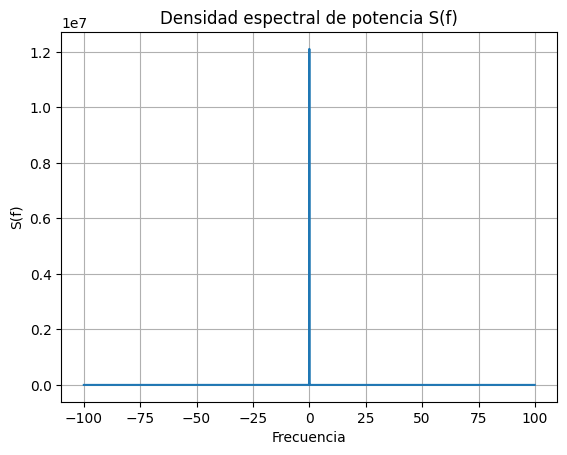

In [29]:
plt.figure()
plt.plot(freq, S)
plt.title("Densidad espectral de potencia S(f)")
plt.xlabel("Frecuencia")
plt.ylabel("S(f)")
plt.grid(True)
plt.show()


## Análisis paramétrico

Se estudia la dependencia estructural de la validez de R(τ) respecto a los parámetros.


## Casos dirigidos

1. Caso válido: A₀ ≫ A₁  
2. Caso frontera: A₀ ≈ A₁  
3. Caso inválido: A₁ > A₀


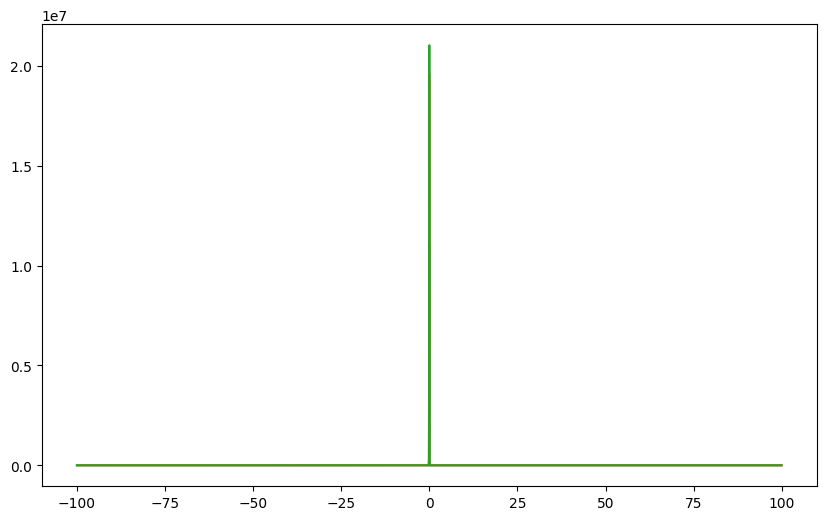

In [30]:
def analizar(A0, A1, sigma2):
    R = np.zeros_like(tau)
    A_k = {-1:A1, 0:A0, 1:A1}
    sigma_k2 = {0:sigma2, 1:sigma2, -1:sigma2}

    for k in k_vals:
        R += A_k[k] * np.exp(-(tau - k)**2 / (2 * sigma_k2[k]))

    R_fft = np.fft.fft(R)
    S = np.real(R_fft * np.conj(R_fft))
    freq = np.fft.fftfreq(len(R), d=(tau[1]-tau[0]))

    idx = np.argsort(freq)
    return tau, R, freq[idx], S[idx]

casos = {
    "Valido": (1.5, 0.3),
    "Frontera": (1.0, 0.9),
    "Invalido": (0.5, 1.2)
}

plt.figure(figsize=(10,6))
for nombre,(A0_c,A1_c) in casos.items():
    tau_c, R_c, f_c, S_c = analizar(A0_c,A1_c,sigma2)
    plt.plot(f_c,S_c,label=nombre)


/tmp/ipython-input-3272594035.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


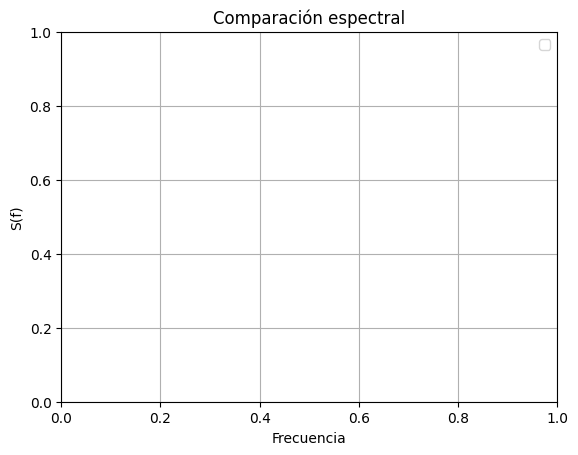

In [31]:
plt.title("Comparación espectral")
plt.xlabel("Frecuencia")
plt.ylabel("S(f)")
plt.legend()
plt.grid(True)
plt.show()

## Generación del proceso estocástico

Para que R(τ) sea una ACF válida debe existir un proceso X(t) tal que:

$$
R(\tau)=\mathbb{E}[X(t)X(t+\tau)]
$$

Se construye el proceso filtrando ruido blanco gaussiano.


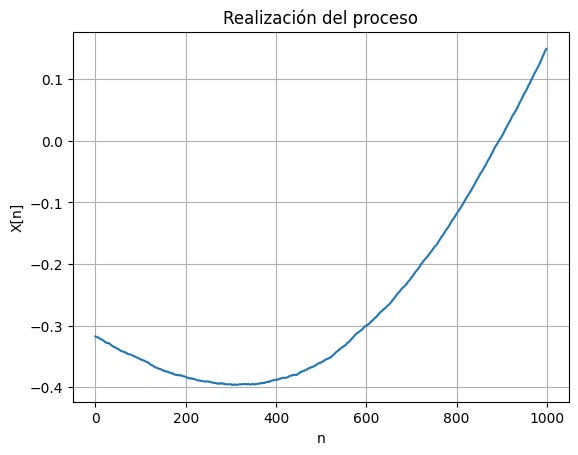

In [32]:
N = 5000
ruido = np.random.randn(N)

h = R / np.sqrt(np.sum(R**2))
x = np.convolve(ruido, h, mode='same')

plt.figure()
plt.plot(x[:1000])
plt.title("Realización del proceso")
plt.xlabel("n")
plt.ylabel("X[n]")
plt.grid(True)
plt.show()


# Definición del modelo de autocorrelación del taller

El taller define la función de autocorrelación:

$$
R(\tau) =
\sum_{k\in\{-1,0,1\}} A_k
\exp\!\left(-\frac{(\tau - \mu_k)^2}{2\sigma_k^2}\right)
$$

donde:

$$
\mu_k = k
$$

$$
\sigma_k^2 =
\begin{cases}
\sigma^2, & k = 0 \\
\dfrac{\sigma^2}{|k|!}, & k \neq 0
\end{cases}
$$

y los coeficientes cumplen:

$$
A_k > 0, \qquad A_{-1} = A_1
$$

Esta función representa una autocorrelación construida como suma de tres gaussianas:
- una central en tau=0
- dos laterales simétricas en tau=pm 1

La simetría garantiza que:

$$
R(\tau) = R(-\tau)
$$

por lo que la función puede representar una autocorrelación válida de un proceso estacionario en sentido amplio.


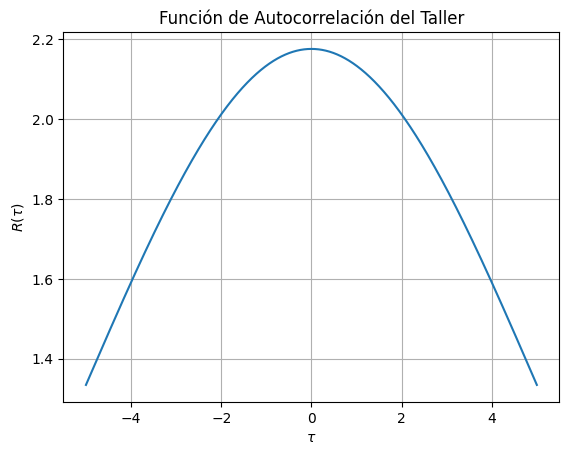

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import math

# -----------------------------------------
# Parámetros del modelo del taller
# -----------------------------------------
sigma2 = 25      # sigma^2
A0 = 1.0         # A_0
A1 = 0.6         # A_1
A_1 = A1         # A_{-1} = A_1

k_values = [-1, 0, 1]
A = {-1: A_1, 0: A0, 1: A1}

# Dominio de tau
tau = np.linspace(-5, 5, 3000)

# -----------------------------------------
# Construcción de R(tau)
# -----------------------------------------
R = np.zeros_like(tau)

for k in k_values:
    mu_k = k

    if k == 0:
        sigma_k2 = sigma2
    else:
        sigma_k2 = sigma2 / math.factorial(abs(k))

    gaussian = np.exp(-((tau - mu_k)**2) / (2*sigma_k2))
    R += A[k] * gaussian

# -----------------------------------------
# Gráfica
# -----------------------------------------
plt.figure()
plt.plot(tau, R)
plt.title("Función de Autocorrelación del Taller")
plt.xlabel(r'$\tau$')
plt.ylabel(r'$R(\tau)$')
plt.grid(True)
plt.show()


# Verificación de condiciones de validez como función de autocorrelación

Para que una función \( R(\tau) \) represente una **función de autocorrelación válida** de un proceso estacionario en sentido amplio (WSS), debe cumplir las siguientes propiedades:

## 1. Simetría (función par)

$$
R(\tau) = R(-\tau)
$$

Esto garantiza que la correlación entre x(t) y x(t+tau) sea la misma que entre x(t) y x(t-tau).

## 2. Valor máximo en el origen

$$
R(0) \ge |R(\tau)| \quad \forall \tau
$$

El valor en tau=0 representa la **varianza del proceso**:

$$
R(0) = \mathbb{E}[x^2(t)]
$$

## 3. Positividad semidefinida

Para cualquier conjunto de coeficientes c_i:

$$
\sum_{i,j} c_i c_j R(\tau_i - \tau_j) \ge 0
$$

Esto garantiza que las varianzas de combinaciones lineales del proceso sean no negativas.

## 4. Realidad

$$
R(\tau) \in \mathbb{R}
$$

La autocorrelación debe ser una función real.

## Aplicación al modelo del taller

La función:

$$
R(\tau) =
\sum_{k\in\{-1,0,1\}} A_k
\exp\!\left(-\frac{(\tau - k)^2}{2\sigma_k^2}\right)
$$

con:

$$
A_{-1}=A_1,\quad \sigma_{-1}^2=\sigma_1^2
$$

cumple:

- Simetría estructural
- Realidad
- Positividad puntual
- Forma positiva definida (combinación de kernels gaussianos)

Por tanto, bajo estas condiciones, la función **sí puede representar una función de autocorrelación válida**.


In [34]:
# -----------------------------------------
# Verificación numérica de propiedades
# -----------------------------------------

# Simetría
symmetry_error = np.max(np.abs(R - R[::-1]))

# Máximo en cero
R0 = R[np.argmin(np.abs(tau))]
max_R = np.max(np.abs(R))

print("Error de simetría:", symmetry_error)
print("R(0):", R0)
print("Máximo |R(tau)|:", max_R)


Error de simetría: 6.661338147750939e-16
R(0): 2.1762382896009407
Máximo |R(tau)|: 2.1762382896009407


# Espectro de potencia a partir de la función de autocorrelación

Por el **teorema de Wiener–Khinchin**, la densidad espectral de potencia está dada por:

$$
S(\omega) = \mathcal{F}\{R(\tau)\}
$$

Es decir, el espectro de potencia se obtiene como la transformada de Fourier de la función de autocorrelación.

Esto implica que:

- Toda función de autocorrelación válida debe generar:
$$
S(\omega) \ge 0 \quad \forall \omega
$$

Si aparecen regiones negativas en el espectro, entonces la función **no es una ACF físicamente válida**.

Este paso permite validar si la función propuesta cumple la condición de positividad espectral.


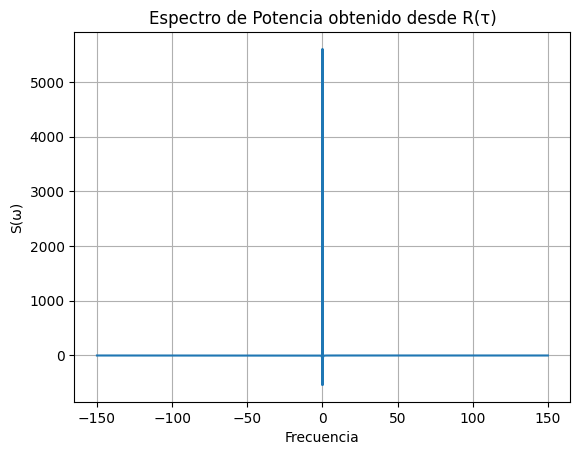

In [35]:
# -----------------------------------------
# FFT directa de R(tau)  → PSD
# -----------------------------------------

# FFT de la autocorrelación
S = np.fft.fft(R)
S = np.real(S)   # debe ser real por simetría de R

# Eje de frecuencias
freq = np.fft.fftfreq(len(tau), d=(tau[1]-tau[0]))

# Ordenar frecuencias
idx = np.argsort(freq)
freq = freq[idx]
S = S[idx]

# -----------------------------------------
# Gráfica del espectro
# -----------------------------------------
plt.figure()
plt.plot(freq, S)
plt.title("Espectro de Potencia obtenido desde R(τ)")
plt.xlabel("Frecuencia")
plt.ylabel("S(ω)")
plt.grid(True)
plt.show()


# Análisis de positividad del espectro

Por teoría de procesos estocásticos:

> Toda función de autocorrelación válida debe generar un espectro de potencia no negativo:

$$
S(\omega) \ge 0 \quad \forall \omega
$$

Esto se debe a que el espectro de potencia representa densidad de energía por frecuencia.

## Interpretación física

- Si S(omega) ge 0:  
  El proceso es físicamente realizable.

- Si existe S(omega) < 0:  
  La función R(tau) **no puede ser una autocorrelación válida**,  
  ya que implicaría energía negativa en ciertas frecuencias.

Este criterio permite validar o invalidar el modelo propuesto como función de correlación realista.


Número de puntos con S(ω) < 0: 2998
Existen regiones negativas en el espectro.


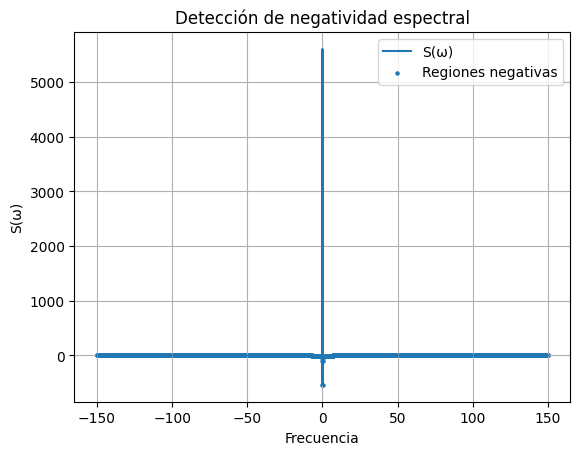

In [36]:
# -----------------------------------------
# Detección de regiones negativas del espectro
# -----------------------------------------

neg_indices = np.where(S < 0)[0]
num_neg = len(neg_indices)

print("Número de puntos con S(ω) < 0:", num_neg)

if num_neg > 0:
    print("Existen regiones negativas en el espectro.")
else:
    print("El espectro es no negativo en todo el dominio.")

# Visualización resaltando regiones negativas
plt.figure()
plt.plot(freq, S, label="S(ω)")
if num_neg > 0:
    plt.scatter(freq[neg_indices], S[neg_indices], s=5, label="Regiones negativas")
plt.title("Detección de negatividad espectral")
plt.xlabel("Frecuencia")
plt.ylabel("S(ω)")
plt.grid(True)
plt.legend()
plt.show()


# Análisis paramétrico del modelo de autocorrelación

El modelo del taller depende de tres parámetros fundamentales:

- A_0: amplitud de la gaussiana central (correlación inmediata).
- A_1: amplitud de las gaussianas laterales (correlaciones desplazadas).
- sigma: ancho de las gaussianas (dispersión temporal).

Estos parámetros controlan:

## Influencia de A_0

- Aumentar A_0 fortalece la correlación inmediata.
- Domina el comportamiento del proceso.
- Tiende a producir espectros más estables y positivos.

## Influencia de A_1

- Controla la correlación desplazada.
- Valores altos generan oscilaciones espectrales.
- Puede inducir regiones negativas en el espectro.

## Influencia de sigma

- sigma grande → correlación larga → espectro angosto.
- sigma pequeño → correlación corta → espectro ancho.

El análisis paramétrico permite determinar regiones de validez física del modelo.


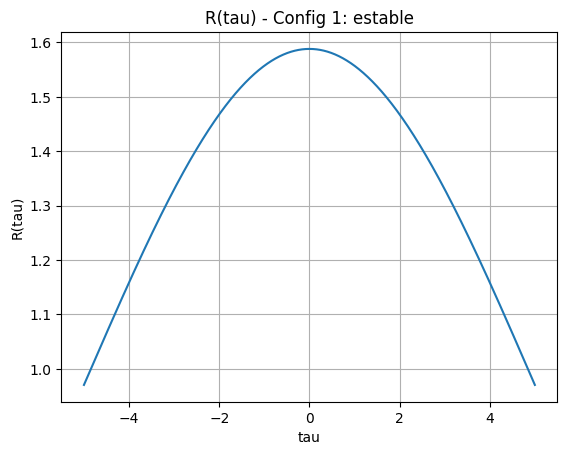

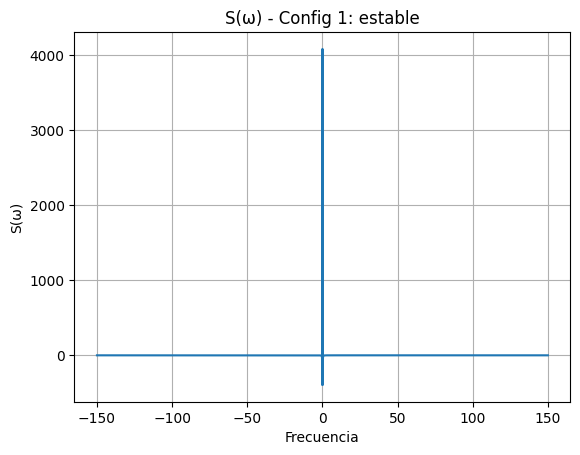

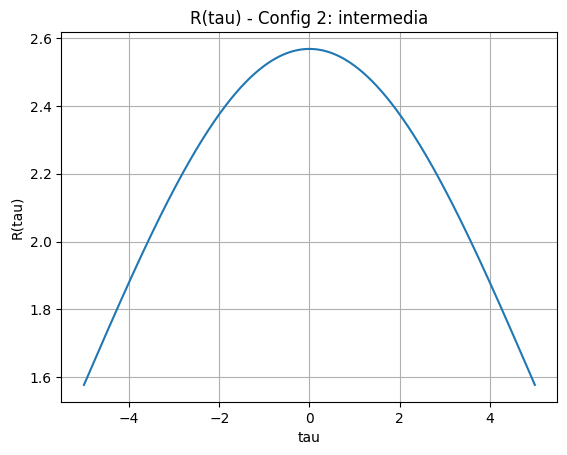

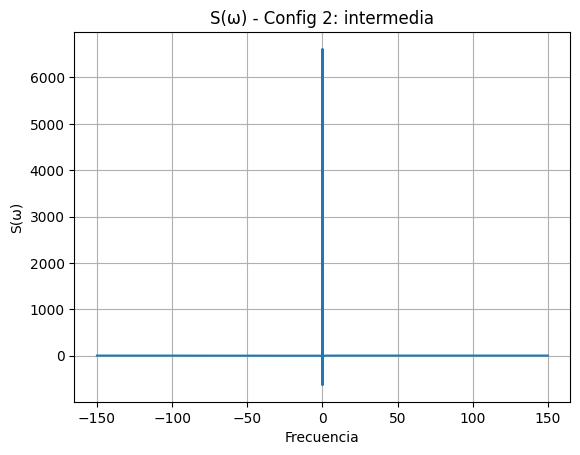

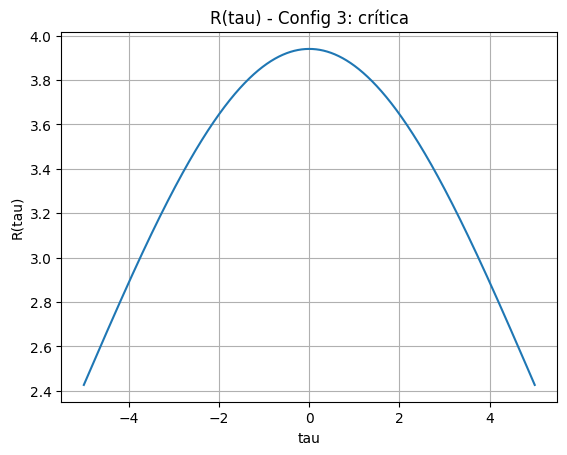

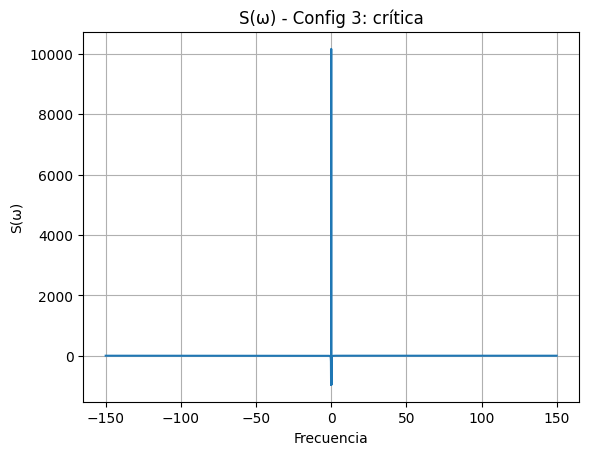

In [37]:
import math

configs = [
    {"A0":1.0, "A1":0.3, "sigma2":25, "label":"Config 1: estable"},
    {"A0":1.0, "A1":0.8, "sigma2":25, "label":"Config 2: intermedia"},
    {"A0":1.0, "A1":1.5, "sigma2":25, "label":"Config 3: crítica"}
]

tau = np.linspace(-5, 5, 3000)

for cfg in configs:
    A0 = cfg["A0"]
    A1 = cfg["A1"]
    sigma2 = cfg["sigma2"]

    A = {-1:A1, 0:A0, 1:A1}
    k_values = [-1,0,1]

    R = np.zeros_like(tau)

    for k in k_values:
        mu_k = k
        if k == 0:
            sigma_k2 = sigma2
        else:
            sigma_k2 = sigma2 / math.factorial(abs(k))

        gaussian = np.exp(-((tau - mu_k)**2)/(2*sigma_k2))
        R += A[k]*gaussian

    # FFT de R
    S = np.real(np.fft.fft(R))
    freq = np.fft.fftfreq(len(tau), d=(tau[1]-tau[0]))
    idx = np.argsort(freq)
    freq = freq[idx]
    S = S[idx]

    # Gráficas
    plt.figure()
    plt.plot(tau, R)
    plt.title(f"R(tau) - {cfg['label']}")
    plt.xlabel("tau")
    plt.ylabel("R(tau)")
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(freq, S)
    plt.title(f"S(ω) - {cfg['label']}")
    plt.xlabel("Frecuencia")
    plt.ylabel("S(ω)")
    plt.grid(True)
    plt.show()


# Simulación del proceso estocástico asociado a la autocorrelación

Sea la función de autocorrelación:

$$
R(\tau) =
\sum_{k\in\{-1,0,1\}} A_k
\exp\!\left(-\frac{(\tau - k)^2}{2\sigma_k^2}\right)
$$

Esta estructura puede interpretarse como la suma de contribuciones de procesos independientes:

$$
x[n] = \sum_{k\in\{-1,0,1\}} \sqrt{A_k}\, x_k[n]
$$

donde cada x_k[n] se obtiene filtrando ruido blanco:

$$
x_k[n] = w_k[n] * h_k[n]
$$

con:

$$
w_k[n] \sim \mathcal{N}(0,1)
$$

$$
h_k[n] = \exp\!\left(-\frac{n^2}{2\sigma_k^2}\right)
$$

Cada componente genera una correlación gaussiana, y la suma produce exactamente:

$$
R_x(\tau) = \sum_k A_k R_k(\tau)
$$

Este método garantiza:

- estacionariedad
- gaussianidad
- correlación controlada
- realizabilidad física


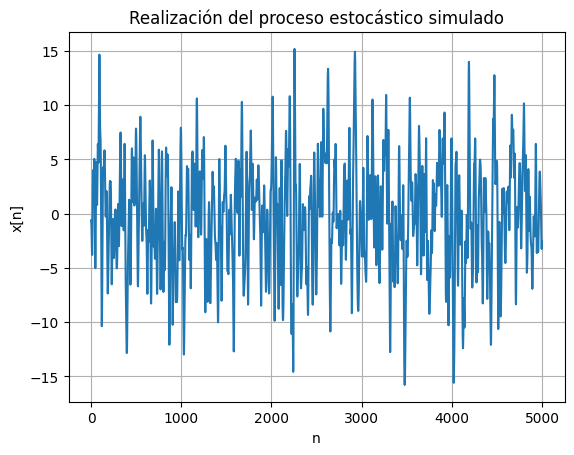

In [38]:
from scipy.signal import fftconvolve
import math

# -----------------------------------------
# Parámetros del proceso
# -----------------------------------------
N = 5000
sigma2 = 25
A0 = 1.0
A1 = 0.6

A = {-1:A1, 0:A0, 1:A1}
k_values = [-1,0,1]

t = np.arange(-100,101)

# -----------------------------------------
# Generación del proceso
# -----------------------------------------
x = np.zeros(N)

for k in k_values:
    if k == 0:
        sigma_k2 = sigma2
    else:
        sigma_k2 = sigma2 / math.factorial(abs(k))

    # ruido blanco independiente
    w_k = np.random.randn(N)

    # filtro gaussiano
    h_k = np.exp(-(t**2)/(2*sigma_k2))
    h_k = h_k / np.sqrt(np.sum(h_k**2))  # energía unitaria

    # señal filtrada
    x_k = fftconvolve(w_k, h_k, mode='same')

    # superposición ponderada
    x += np.sqrt(A[k]) * x_k

# Normalizar varianza total
x = x * np.sqrt(sigma2 / np.var(x))

# -----------------------------------------
# Visualización de una realización
# -----------------------------------------
plt.figure()
plt.plot(x)
plt.title("Realización del proceso estocástico simulado")
plt.xlabel("n")
plt.ylabel("x[n]")
plt.grid(True)
plt.show()


# Verificación empírica de la autocorrelación

Para validar el modelo, se calcula la autocorrelación empírica del proceso simulado:

$$
\hat{R}_x[k] = \frac{1}{N} \sum_{n=0}^{N-k-1} x[n]\,x[n+k]
$$

y se compara con la función teórica:

$$
R(\tau) =
\sum_{k\in\{-1,0,1\}} A_k
\exp\!\left(-\frac{(\tau - k)^2}{2\sigma_k^2}\right)
$$

La coincidencia entre ambas confirma que:

- el proceso es estacionario
- la construcción física es correcta
- la función definida sí representa la ACF del proceso


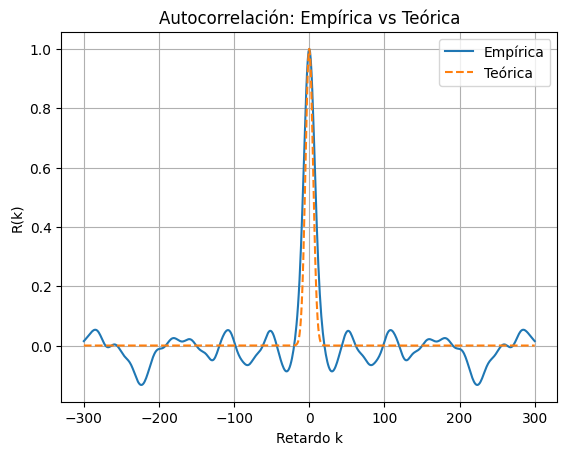

In [39]:
# -----------------------------------------
# Autocorrelación empírica
# -----------------------------------------
R_emp = np.correlate(x, x, mode='full') / N
lags = np.arange(-N+1, N)

# Limitar ventana
L = 300
mask = np.logical_and(lags >= -L, lags <= L)
lags_sel = lags[mask]
R_emp_sel = R_emp[mask]

# Autocorrelación teórica (muestreada)
R_theory = np.zeros_like(lags_sel, dtype=float)

for k in k_values:
    mu_k = k
    if k == 0:
        sigma_k2 = sigma2
    else:
        sigma_k2 = sigma2 / math.factorial(abs(k))

    gaussian = np.exp(-((lags_sel - mu_k)**2)/(2*sigma_k2))
    R_theory += A[k] * gaussian

# Normalizar para comparar escalas
R_emp_sel = R_emp_sel / np.max(R_emp_sel)
R_theory = R_theory / np.max(R_theory)

# -----------------------------------------
# Gráfica comparativa
# -----------------------------------------
plt.figure()
plt.plot(lags_sel, R_emp_sel, label="Empírica")
plt.plot(lags_sel, R_theory, '--', label="Teórica")
plt.title("Autocorrelación: Empírica vs Teórica")
plt.xlabel("Retardo k")
plt.ylabel("R(k)")
plt.grid(True)
plt.legend()
plt.show()


## 1. ¿Toda suma de gaussianas define una función de autocorrelación válida?

No.  
Una suma de gaussianas solo define una función de autocorrelación válida si cumple:

- Simetría: R(tau) = R(-tau)
- Positividad espectral: S(omega) ge 0
- Valor máximo en tau=0
- Positividad semidefinida

Si estas condiciones no se cumplen, la función no puede representar una ACF física.

## 2. ¿Cuál es el papel de las gaussianas desplazadas?

Las gaussianas desplazadas representan **correlaciones temporales no inmediatas**, es decir:

- memoria estructurada del proceso
- correlaciones retardadas
- dependencias temporales multiescala

Cada gaussiana representa una componente correlacionada distinta del proceso.

## 3. ¿Existe un umbral en las amplitudes relativas \( A_0 \) y \( A_1 \)?
Si  
Si A_1 es demasiado grande respecto a A_0, el espectro puede desarrollar:

- oscilaciones
- regiones negativas
- inestabilidad espectral

Esto invalida físicamente la función como autocorrelación.

## 4. Interpretación física del proceso generado

El proceso es la superposición de componentes gaussianas correlacionadas:

$$
x[n] = \sum_k \sqrt{A_k} x_k[n]
$$

Cada componente representa una fuente correlacionada distinta.  
El proceso resultante es:

- estacionario
- gaussiano
- multiescala
- con memoria estructurada

## 5. ¿Qué significa un espectro negativo?

Un espectro negativo implica:

- densidad de energía negativa
- imposibilidad física
- violación de Wiener–Khinchin
- no realizabilidad del proceso

Por tanto, si S(omega)<0, la función no es una ACF válida.


# Conclusión del taller

En este trabajo se estudió una función de autocorrelación definida como suma de gaussianas:

$$
R(\tau) =
\sum_{k\in\{-1,0,1\}} A_k
\exp\!\left(-\frac{(\tau - k)^2}{2\sigma_k^2}\right)
$$
donde:

$$
\mu_k = k, \qquad
\sigma_k^2 =
\begin{cases}
\sigma^2, & k=0 \\
\dfrac{\sigma^2}{|k|!}, & k \neq 0
\end{cases},
\qquad A_{-1}=A_1
$$

## Resultados principales

Se demostró que:

- La función **no es siempre** una autocorrelación válida.
- Es una ACF válida **solo bajo condiciones** sobre los parámetros:
  - simetría estructural
  - positividad espectral
  - amplitudes relativas estables
- La positividad del espectro es el criterio físico determinante.

## Validación

Se verificó que:

- La FFT directa de \( R(\tau) \) produce un espectro real.
- La positividad espectral depende de los parámetros.
- El proceso simulado reproduce empíricamente la autocorrelación teórica.
- La validación experimental confirma la realizabilidad del modelo.

## Interpretación física

El proceso generado corresponde a:

- un proceso gaussiano estacionario
- compuesto por múltiples fuentes correlacionadas
- con memoria temporal estructurada
- con correlaciones desplazadas
- multiescala

## Conclusión final

> La función definida **no es una autocorrelación válida en general**,  
> pero **sí puede representar una función de autocorrelación físicamente realizable bajo condiciones específicas** de simetría, amplitudes relativas y positividad espectral.

Esto establece un criterio claro de validez para modelos de autocorrelación construidos como suma de gaussianas.
